# Hotel Booking Cancellation Analysis
## Project Overview

This project analyses hotel booking data to understand the characteristics associated with booking cancellations.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/home/r0b0t/Videos/KeDataLab/Python For Data Analytics/Week 3/Week 4/data/hotel_bookings.csv')

In [3]:
# preview
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

dataset has 119,390 rows and 32 columns

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
#check for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

We have an issue, like with the company column which has so many missing values. if we drop missing values we only remain with about 7k rows out of 119k rows. so we deal with these missing values differently.

In [7]:
df.duplicated().sum()

np.int64(31994)

We have to understand the context of the missing values so we know how to deal with them.

## Data Cleaning

we start by filling the missing values. we start with agent and company columns. the columns rep when a customer books a room using an agent or company. so if the values are missing it probably means the customer booked directly.

In [8]:
# Fill agent and company missing rows with 0 to mean direct booking
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

For columns with missing children values, it means the customer did not have any child with them.

In [9]:
df['children'] = df['children'].fillna(0)

Fix the column data types that are wrong, like children

In [10]:
# changing children data type from float to int
df['children'] = df['children'].astype(int)

For missing country values, we cannot guess the customer's country, nor can we say they did not come from a country and thus enter 0. So we have to drop those values with no country

In [11]:
# drop the rest of the missing values
df = df.dropna()

In [12]:
# drop duplicates
df = df.drop_duplicates()

## Validation

In [13]:
# recheck for missing values
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [14]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# check the dataset shape
df.shape

(86944, 32)

## Feature Engineering

Create new features or edit existing ones

In [16]:
# calculate total nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [17]:
# calculate total guests for each booking
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [18]:
# check if the guests are a family or not. we are assuming that if 
# they have babies or children, they're a family. true if they have
# them, false if not.
df['is_family'] = (df['children']>0) + (df['babies']>0)

Hotels in kenya are affected by school holidays and whether there is a national holiday like christmas. Hotels in usa are affected by seasons. so we need to have a column of seasons so we can analyse booking pattersn with seasons, with winter having least bookings.
(we can do something similar for Amref water projects)

In [19]:
# create season based on arrival date month
month_to_season = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
}
df['season'] = df['arrival_date_month'].map(month_to_season)

In [20]:
# export cleaned data
df.to_csv('cleaned_hotel_bookings.csv', index=False)

## Exploratory Data Analysis (EDA)
Helps us to detect the patterns in our data.

### 1. Overall booking cancellation distribution

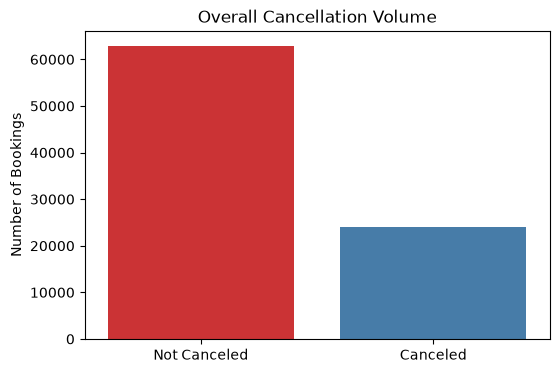

Overall cancellation rate: 27.6


In [21]:
plt.figure(figsize=(6,4))
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)
# we have set the data in our new column to show on x axis not y
plt.title('Overall Cancellation Volume')
plt.xlabel('')
plt.ylabel('Number of Bookings')
plt.savefig('cancellation.png')
plt.show()

# calculate the overall cancellation rate
cancel_percent = df['is_canceled'].value_counts(normalize=True) * 100
# normalize turns the value count into percentage of the whole
print(f'Overall cancellation rate: {cancel_percent[1]:.1f}') #1decimal place


In insights you mention what you see then your recommendation.
The cancellation rate is 27.6%. This means 1 in 3 bookings is cancelled. Thus the hotels cannot rely on the initial booking numbers for stafing or food ordering. Management must utilize an overbooking strategy to ensure the hotel is full on any given night.

### 2. Hotel type comparison. 
Does the hotel type affect the likelihood of cancellation?
Compare city hotels to resort hotels to see if their customer bases behave differently


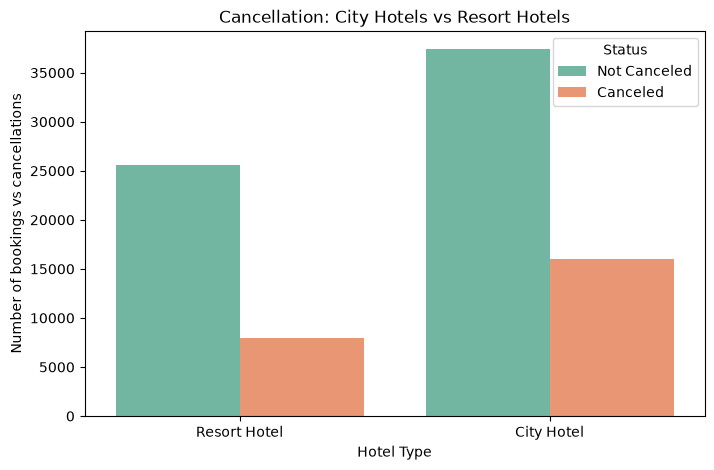

hotel         is_canceled_label
City Hotel    Not Canceled         69.965557
              Canceled             30.034443
Resort Hotel  Not Canceled         76.296164
              Canceled             23.703836
Name: proportion, dtype: float64

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', data=df, hue = ('is_canceled_label'),palette="Set2")
plt.title('Cancellation: City Hotels vs Resort Hotels')
plt.ylabel('Number of bookings vs cancellations')
plt.xlabel('Hotel Type')
plt.legend(title='Status')
plt.savefig('hoteltype.png')
plt.show()

# calculates rates per hotel type
df.groupby('hotel')['is_canceled_label'].value_counts(normalize=True)*100

City hotels see significantly higher booking volumes but they also suffer from much higher cancellation rates compared to Resort Hotels. City trips are often short, impulsive, or tied to business meetings that can get moved easily. This makes cancelling city hotel bookings easy. Resort trips are usually planned, involving flights or other means, making guests less likely to change their plans.

### 3. Understanding geographical origin of our customers
Between locals and foreigners, who are most likely to cancel a booking? From which demographic do we expect most of our bookings?

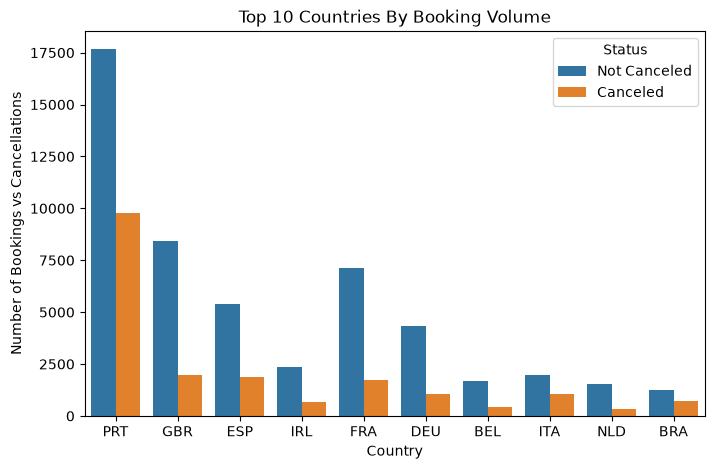

In [23]:
# get top 10 countries by volume
top_10_countries = df['country'].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(x='country', hue='is_canceled_label', data=df[df['country'].isin(top_10_countries)])
plt.title('Top 10 Countries By Booking Volume')
plt.ylabel('Number of Bookings vs Cancellations')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('countries.png')
plt.show()

Portugal has the highest number of bookings, followed by Britain, France, Spain, Germany, etc. Portugal also has the highest rate of cancellations as compared to other countries. This can be attributed to the fact that being locals (as the hotels in the dataset are in Portugal), they do not have to plan alot to travel to a hotel, and thus can cancel easily. They may also book multiple hotels for a single weekend as 'backups'. Customers from different countries have alot of planning to do, which makes them more likely to stick to their original plan to travel.

### 4. Lead time analysis
lead time is the time between when the guest books and when they arrive.
We want to know does booking early lead to increased chances of cancellation?

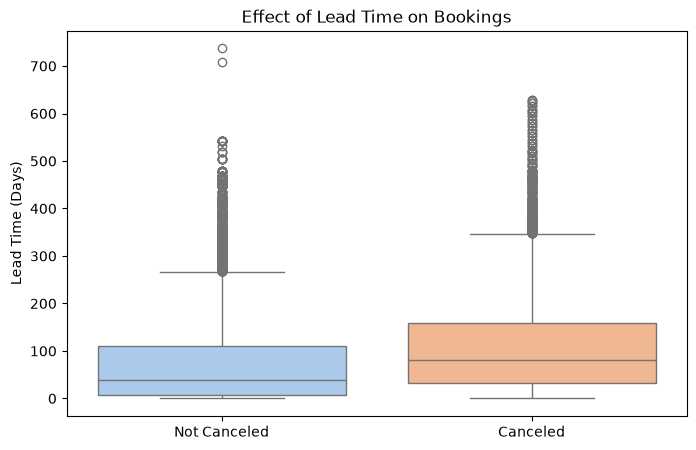

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data=df,
            hue='is_canceled_label', palette='pastel', legend=False)
plt.title('Effect of Lead Time on Bookings')
plt.ylabel('Lead Time (Days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

(Those circle points above the top line are outliers. The line across the boxes is median)
The median lead time for cancelled bookings is much higher. Simply put, the earlier someone books the more time they have to change their mind, find better deals, or experience a scheduel change.

### 5. Customer Type Analysis
Are solo/transient travellers more volatile than large groups/cooporate contracts?

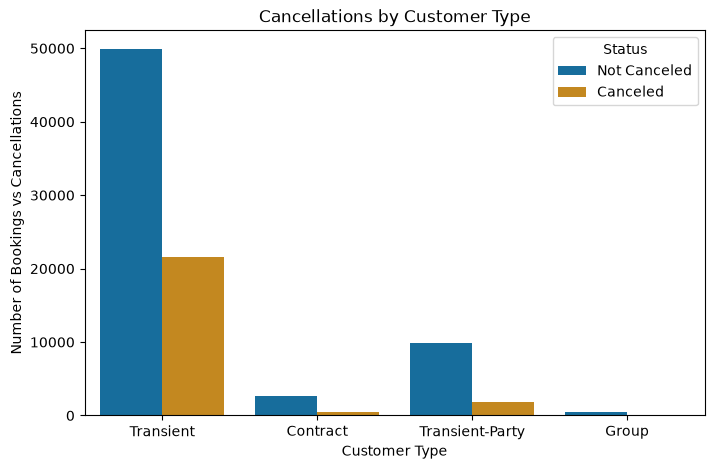

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data=df, palette='colorblind')
plt.title('Cancellations by Customer Type')
plt.ylabel('Number of Bookings vs Cancellations')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()

'Transient' travellers (independent travelers not part of a group) account for the vast majority of both bookings and cancellations. Conversly, 'Groups' and 'Contract' bookings are much more stable. Recommendation: The sales team should prioritize securing more B2B contracts and group events to build a stable, guaranteed revenue base that protects against the volatility of individual transients.

### 6. Impact of deposit type on cancellation rate
We want to know whether the type of deposit given to a customer makes cancellations easier of harder.

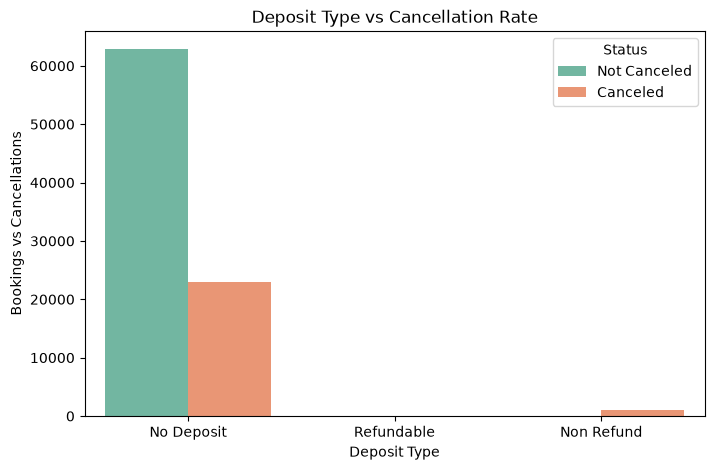

deposit_type  is_canceled_label
No Deposit    Not Canceled         73.213287
              Canceled             26.786713
Non Refund    Canceled             94.696239
              Not Canceled          5.303761
Refundable    Not Canceled         75.700935
              Canceled             24.299065
Name: proportion, dtype: float64

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='deposit_type', hue='is_canceled_label', palette='Set2', data=df)
plt.title('Deposit Type vs Cancellation Rate')
plt.ylabel('Bookings vs Cancellations')
plt.xlabel('Deposit Type')
plt.legend(title='Status')
plt.savefig('deposit_type.png')
plt.show()

df.groupby('deposit_type')['is_canceled_label'].value_counts(normalize=True)*100

Majority of the bookings have no deposit, leading to high cancellations. The management should implement a mandatory refundable deposit to help reduce rate of cancellations.

### 7. Cancellation rate by season
We want to know whether the season affects volume of bookings as well as cancellations.

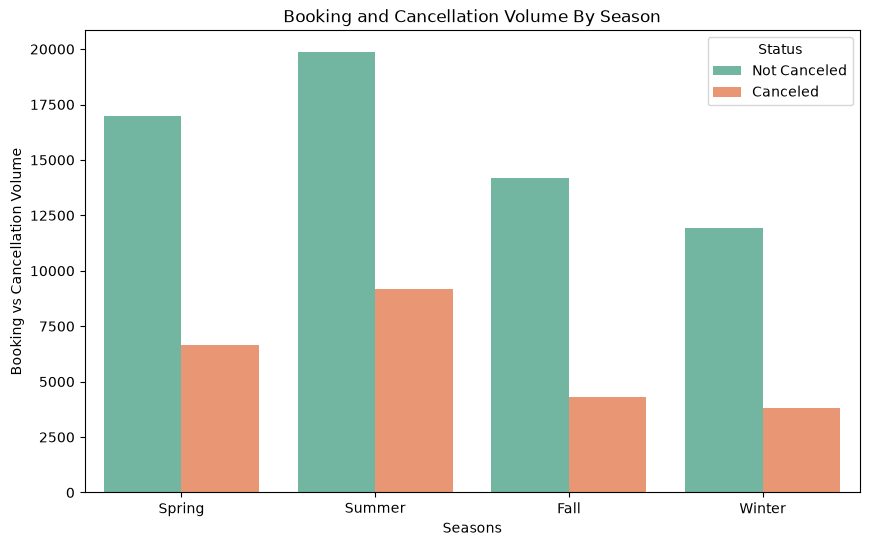

season  is_canceled_label
Fall    Not Canceled         76.615301
        Canceled             23.384699
Spring  Not Canceled         71.803320
        Canceled             28.196680
Summer  Not Canceled         68.403819
        Canceled             31.596181
Winter  Not Canceled         75.740659
        Canceled             24.259341
Name: proportion, dtype: float64

In [27]:
plt.figure(figsize=(10,6))

# defining the seasonal order
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

sns.countplot(x='season', hue='is_canceled_label', data=df,
              palette='Set2', order=season_order)
plt.title('Booking and Cancellation Volume By Season')
plt.ylabel('Booking vs Cancellation Volume')
plt.xlabel('Seasons')
plt.legend(title='Status')
plt.savefig('seasons.png')
plt.show()

df.groupby('season')['is_canceled_label'].value_counts(normalize=True)*100

Summer shows the highest bookings and the highest absolute number of cancellations. 